# Loan Prediction – Feature Engineering & Data Preprocessing

## AnalystLab Africa Data Science Internship – Week 2

### Project Objective

This project focuses on preparing a loan prediction dataset for machine learning.

The analysis involves inspecting, cleaning, transforming, encoding, scaling, and engineering features to produce a high-quality machine-learning-ready dataset.

The objective is to identify relevant features and prepare the data for predicting whether a loan application should be approved.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part 2: Data Inspection

In this section, the Loan Prediction dataset is inspected to understand its structure, data types, completeness, and overall quality before preprocessing.

The inspection covers:

- Displaying the first 10 rows
- Checking the number of rows and columns
- Examining column names and data types
- Identifying missing values
- Checking for duplicate records
- Reviewing summary statistics

In [4]:
import kagglehub
import os

# Download the Loan Prediction dataset from Kaggle
path = kagglehub.dataset_download(
    "altruistdelhite04/loan-prediction-problem-dataset"
)

print("Path to dataset files:", path)

Path to dataset files: C:\Users\HP\.cache\kagglehub\datasets\altruistdelhite04\loan-prediction-problem-dataset\versions\1


In [5]:
os.listdir(path)

['test_Y3wMUE5_7gLdaTN.csv', 'train_u6lujuX_CVtuZ9i.csv']

In [6]:
# Load the training dataset
df = pd.read_csv(
    os.path.join(path, "train_u6lujuX_CVtuZ9i.csv")
)

# Display the first 10 rows
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


### Dataset Structure

The Loan Prediction dataset is inspected to understand its size, variables, data types, missing values, duplicate records, and statistical characteristics before preprocessing.

In [7]:
df.shape

(614, 13)

### Column Names

The column names are examined to understand the variables available for the loan prediction problem and to identify the target variable.

In [8]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

### Data Types

The data types of each variable are examined to distinguish numerical and categorical features and identify any variables that may require correction during preprocessing.

In [9]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

### Dataset Information

The dataset information is reviewed to examine the number of observations, non-null values, data types, and memory usage.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


### Missing Value Assessment

Missing values are assessed for each variable. Identifying missing data is important because incomplete observations may affect feature engineering and machine learning model performance.

In [11]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [12]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

Credit_History       8.143322
Self_Employed        5.211726
LoanAmount           3.583062
Dependents           2.442997
Loan_Amount_Term     2.280130
Gender               2.117264
Married              0.488599
Loan_ID              0.000000
Education            0.000000
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

### Duplicate Records

The dataset is checked for duplicate records to determine whether identical observations are present.

In [13]:
df.duplicated().sum()

0

### Summary Statistics

Descriptive statistics are generated to understand the distribution, central tendency, and range of the numerical variables.

In [14]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [15]:
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


### Target Variable: Loan Status

The target variable for this prediction problem is `Loan_Status`. It indicates whether a loan application was approved or rejected.

The distribution of the target variable is examined to understand the proportion of approved and rejected applications.

In [16]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [17]:
df['Loan_Status'].value_counts(normalize=True) * 100

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

## Part 3: Feature Engineering & Data Preprocessing

The next stage focuses on preparing the Loan Prediction dataset for machine learning. The preprocessing workflow includes data cleaning, feature engineering, categorical encoding, feature scaling, outlier detection, and feature selection.

In [18]:
# Create a copy of the original dataset for preprocessing
df_clean = df.copy()

# Display the shape of the working dataset
df_clean.shape

(614, 13)

### Missing Value Treatment

Missing values were identified during the data inspection stage. Instead of removing rows with missing observations, appropriate imputation techniques are applied to preserve the available data.

Categorical variables are imputed using their mode because these variables represent categories. LoanAmount is imputed using the median because loan amounts may contain extreme values that could influence the mean. Loan_Amount_Term and Credit_History are treated using their most frequent values.

In [19]:
# Display missing values before treatment
print("Missing values before treatment:")
print(df_clean.isnull().sum())

Missing values before treatment:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [20]:
# Fill missing categorical values with the mode
categorical_impute = ['Gender', 'Married', 'Dependents', 'Self_Employed']

for column in categorical_impute:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

# Fill LoanAmount with the median
df_clean['LoanAmount'] = df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].median())

# Fill Loan_Amount_Term with the mode
df_clean['Loan_Amount_Term'] = df_clean['Loan_Amount_Term'].fillna(
    df_clean['Loan_Amount_Term'].mode()[0]
)

# Fill Credit_History with the mode
df_clean['Credit_History'] = df_clean['Credit_History'].fillna(
    df_clean['Credit_History'].mode()[0]
)

# Check missing values after treatment
print("Missing values after treatment:")
print(df_clean.isnull().sum())

Missing values after treatment:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


### Duplicate Record Treatment

The dataset was checked for duplicate records. No duplicate rows were identified, so no records were removed at this stage.

In [21]:
# Check for duplicate records
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [22]:
# Remove duplicates if any exist
df_clean = df_clean.drop_duplicates()

print("Dataset shape after duplicate removal:", df_clean.shape)

Dataset shape after duplicate removal: (614, 13)


### Data Type Validation

The data types of the variables were reviewed to ensure that numerical variables are represented numerically and categorical variables remain suitable for encoding. Credit_History is converted to an integer after missing values have been handled.

In [23]:
# Convert Credit_History to integer
df_clean['Credit_History'] = df_clean['Credit_History'].astype(int)

# Display updated data types
df_clean.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History         int32
Property_Area         object
Loan_Status           object
dtype: object

### Export Cleaned Dataset

After handling missing values, duplicate records, and data type validation, the cleaned dataset is exported as a CSV file. This version retains the original feature structure before machine learning transformations such as encoding and scaling.

In [24]:
# Save the cleaned dataset
df_clean.to_csv(
    'Loan_Prediction_Cleaned_Dataset.csv',
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


### Feature Engineering

Feature engineering is used to create additional variables that may provide useful information for predicting loan approval.

A new feature called `TotalIncome` is created by combining `ApplicantIncome` and `CoapplicantIncome`. This represents the total income available to the loan application.

This feature may improve predictive performance because loan repayment capacity can depend on the combined income of the applicant and coapplicant.

In [25]:
# Create a new feature representing the combined income
df_clean['TotalIncome'] = (
    df_clean['ApplicantIncome'] + df_clean['CoapplicantIncome']
)

# Display the new feature
df_clean[['ApplicantIncome', 'CoapplicantIncome', 'TotalIncome']].head(10)

,ApplicantIncome,CoapplicantIncome,TotalIncome
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0
5,5417,4196.0,9613.0
6,2333,1516.0,3849.0
7,3036,2504.0,5540.0
8,4006,1526.0,5532.0
9,12841,10968.0,23809.0


### Removal of Irrelevant Features

`Loan_ID` is removed because it is an identifier rather than a meaningful predictive feature. Including an identifier could introduce noise into the machine learning model without providing useful information about loan approval.

In [26]:
# Remove Loan_ID because it is only an identifier
df_ml = df_clean.drop(columns=['Loan_ID'])

# Check the remaining columns
df_ml.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'TotalIncome'],
      dtype='object')

### Separation of Features and Target Variable

The target variable is `Loan_Status`, which indicates whether a loan application was approved or rejected.

The predictor variables are separated from the target before applying encoding and scaling techniques.

In [27]:
# Separate features from the target variable
X = df_ml.drop(columns=['Loan_Status'])
y = df_ml['Loan_Status']

# Display the shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (614, 12)
Target shape: (614,)


In [28]:
# Encode the target variable
y = y.map({'Y': 1, 'N': 0})

# Check the result
y.value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

### Feature Encoding

Categorical variables must be converted into numerical form before machine learning models can use them. One-hot encoding is applied to nominal categorical variables because these categories do not have a natural numerical order. Binary categorical variables are converted into 0/1 values.

In [29]:
# Create a copy of the cleaned dataset for machine learning preprocessing
df_ml = df_clean.copy()

# Drop Loan_ID because it is an identifier and does not provide predictive information
df_ml = df_ml.drop(columns=['Loan_ID'])

# Convert binary categorical variables to numerical values
df_ml['Gender'] = df_ml['Gender'].map({'Male': 1, 'Female': 0})
df_ml['Married'] = df_ml['Married'].map({'Yes': 1, 'No': 0})
df_ml['Education'] = df_ml['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df_ml['Self_Employed'] = df_ml['Self_Employed'].map({'Yes': 1, 'No': 0})

# Convert target variable to numerical values
df_ml['Loan_Status'] = df_ml['Loan_Status'].map({'Y': 1, 'N': 0})

# One-hot encode Property_Area because it contains three nominal categories
df_ml = pd.get_dummies(
    df_ml,
    columns=['Property_Area'],
    drop_first=True,
    dtype=int
)

# Display the first 10 rows after encoding
df_ml.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,128.0,360.0,1,1,5849.0,0,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1,0,6091.0,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1,1,3000.0,0,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1,1,4941.0,0,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1,1,6000.0,0,1
5,1,1,2,1,1,5417,4196.0,267.0,360.0,1,1,9613.0,0,1
6,1,1,0,0,0,2333,1516.0,95.0,360.0,1,1,3849.0,0,1
7,1,1,3+,1,0,3036,2504.0,158.0,360.0,0,0,5540.0,1,0
8,1,1,2,1,0,4006,1526.0,168.0,360.0,1,1,5532.0,0,1
9,1,1,1,1,0,12841,10968.0,349.0,360.0,1,0,23809.0,1,0


### Converting Dependents to Numerical Values

The Dependents variable contains four categories: 0, 1, 2, and 3+. Since machine learning algorithms require numerical inputs, the 3+ category is represented as 3. This converts the variable into a numerical format while preserving the ordinal relationship between the categories.

In [30]:
# Convert the Dependents column to numerical values
df_ml['Dependents'] = df_ml['Dependents'].replace('3+', '3').astype(int)

# Check the unique values
print("Unique values in Dependents:")
print(df_ml['Dependents'].unique())

# Display the updated data type
print("\nData type:")
print(df_ml['Dependents'].dtype)

# Display the first 10 rows
df_ml.head(10)

Unique values in Dependents:
[0 1 2 3]

Data type:
int32


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,128.0,360.0,1,1,5849.0,0,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1,0,6091.0,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1,1,3000.0,0,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1,1,4941.0,0,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1,1,6000.0,0,1
5,1,1,2,1,1,5417,4196.0,267.0,360.0,1,1,9613.0,0,1
6,1,1,0,0,0,2333,1516.0,95.0,360.0,1,1,3849.0,0,1
7,1,1,3,1,0,3036,2504.0,158.0,360.0,0,0,5540.0,1,0
8,1,1,2,1,0,4006,1526.0,168.0,360.0,1,1,5532.0,0,1
9,1,1,1,1,0,12841,10968.0,349.0,360.0,1,0,23809.0,1,0


### Numerical Data Validation

After encoding the categorical variables and converting Dependents to a numerical representation, the dataset is checked to confirm that all variables are numerical and suitable for machine learning preprocessing.

In [31]:
# Check data types of all variables
print("Data types after encoding and feature engineering:")
print(df_ml.dtypes)

# Check for any remaining non-numerical columns
print("\nNon-numerical columns:")
print(df_ml.select_dtypes(include=['object']).columns.tolist())

Data types after encoding and feature engineering:
Gender                       int64
Married                      int64
Dependents                   int32
Education                    int64
Self_Employed                int64
ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History               int32
Loan_Status                  int64
TotalIncome                float64
Property_Area_Semiurban      int32
Property_Area_Urban          int32
dtype: object

Non-numerical columns:
[]


In [32]:
print("Dataset shape:", df_ml.shape)

Dataset shape: (614, 14)


### Outlier Detection Using the IQR Method

Outliers are observations that are unusually far from the majority of the data. They can negatively influence some machine learning algorithms and statistical analyses.

The Interquartile Range (IQR) method is used to identify potential outliers. The IQR is calculated as the difference between the 75th percentile (Q3) and the 25th percentile (Q1). Values below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR are considered potential outliers.

Boxplots are also used to visually examine the distribution of the numerical variables.

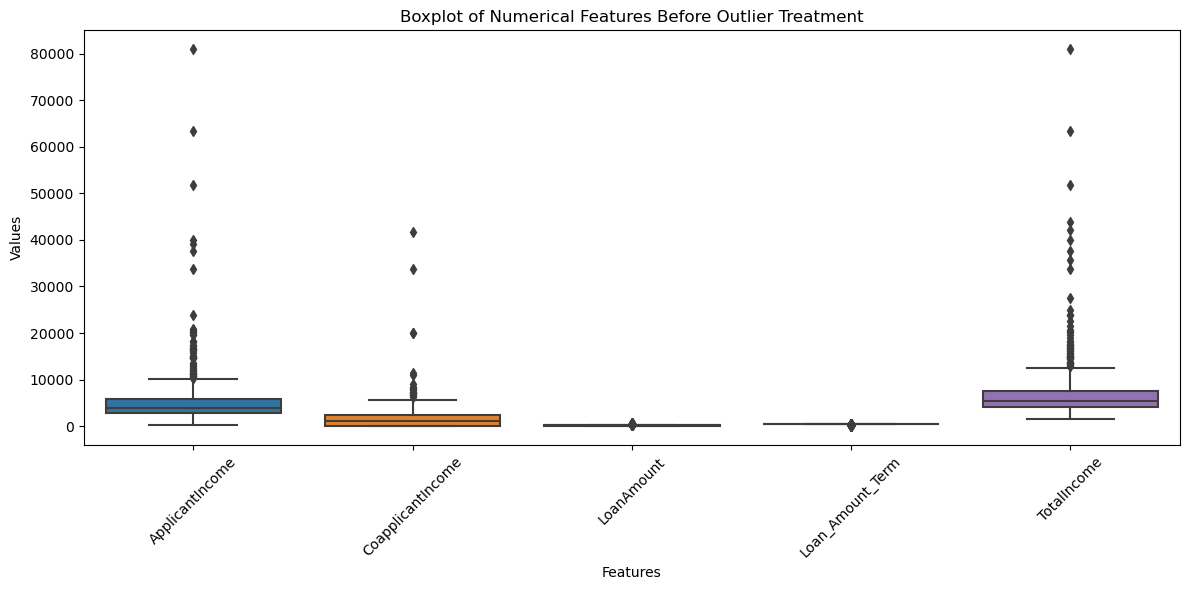

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select continuous numerical variables for outlier analysis
numerical_features = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'TotalIncome'
]

# Create boxplots for numerical variables
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_ml[numerical_features])

plt.title('Boxplot of Numerical Features Before Outlier Treatment')
plt.xlabel('Features')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Quantifying Outliers Using IQR

The number of potential outliers in each continuous numerical feature is calculated using the IQR method. This provides a quantitative basis for deciding how outliers should be handled.

In [34]:
# Calculate the number of outliers using the IQR method

outlier_summary = {}

for column in numerical_features:
    Q1 = df_ml[column].quantile(0.25)
    Q3 = df_ml[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_ml[
        (df_ml[column] < lower_bound) |
        (df_ml[column] > upper_bound)
    ]

    outlier_summary[column] = len(outliers)

# Display outlier counts
outlier_summary

{'ApplicantIncome': 50,
 'CoapplicantIncome': 18,
 'LoanAmount': 41,
 'Loan_Amount_Term': 88,
 'TotalIncome': 50}

### Creating an Outlier Summary Table

In [35]:
# Create a dataframe containing outlier counts and percentages

outlier_table = []

for column in numerical_features:
    Q1 = df_ml[column].quantile(0.25)
    Q3 = df_ml[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df_ml[column] < lower_bound) |
        (df_ml[column] > upper_bound)
    ).sum()

    outlier_percentage = (outlier_count / len(df_ml)) * 100

    outlier_table.append({
        'Feature': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count,
        'Outlier Percentage': outlier_percentage
    })

outlier_df = pd.DataFrame(outlier_table)

outlier_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,ApplicantIncome,2877.50,5795.00,2917.50,-1498.750,10171.250,50,8.143322
1,CoapplicantIncome,0.00,2297.25,2297.25,-3445.875,5743.125,18,2.931596
2,LoanAmount,100.25,164.75,64.50,3.500,261.500,41,6.677524
3,Loan_Amount_Term,360.00,360.00,0.00,360.000,360.000,88,14.332248
4,TotalIncome,4166.00,7521.75,3355.75,-867.625,12555.375,50,8.143322


### Outlier Treatment Using IQR Capping

The IQR method identified potential outliers in several continuous numerical variables. However, `Loan_Amount_Term` is a discrete feature with a highly concentrated distribution, resulting in an IQR of zero. Applying IQR capping to this variable would incorrectly convert legitimate loan terms to 360 months.

Therefore, IQR capping is applied only to the continuous financial variables: `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, and `TotalIncome`.

This approach preserves legitimate loan-term categories while reducing the influence of extreme financial values.

In [36]:
# Recreate the dataset from the original machine-learning dataset
# to undo the previous incorrect treatment of Loan_Amount_Term.

df_ml_outlier_treated = df_ml.copy()

# Apply IQR capping only to continuous financial variables
outlier_features = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'TotalIncome'
]

for column in outlier_features:
    Q1 = df_ml_outlier_treated[column].quantile(0.25)
    Q3 = df_ml_outlier_treated[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_ml_outlier_treated[column] = df_ml_outlier_treated[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier treatment completed successfully.")

Outlier treatment completed successfully.


In [37]:
# Display summary statistics after outlier treatment
df_ml_outlier_treated[outlier_features].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,TotalIncome
count,614.000000,614.000000,614.000000,614.00000
mean,4617.111564,1419.702231,137.365635,6194.72259
std,2479.851729,1624.605892,55.779749,2875.79192
min,150.000000,0.000000,9.000000,1442.00000
25%,2877.500000,0.000000,100.250000,4166.00000
50%,3812.500000,1188.500000,128.000000,5416.50000
75%,5795.000000,2297.250000,164.750000,7521.75000
max,10171.250000,5743.125000,261.500000,12555.37500


In [38]:
print("Loan Amount Term values after outlier treatment:")
print(sorted(df_ml_outlier_treated['Loan_Amount_Term'].unique()))

Loan Amount Term values after outlier treatment:
[12.0, 36.0, 60.0, 84.0, 120.0, 180.0, 240.0, 300.0, 360.0, 480.0]


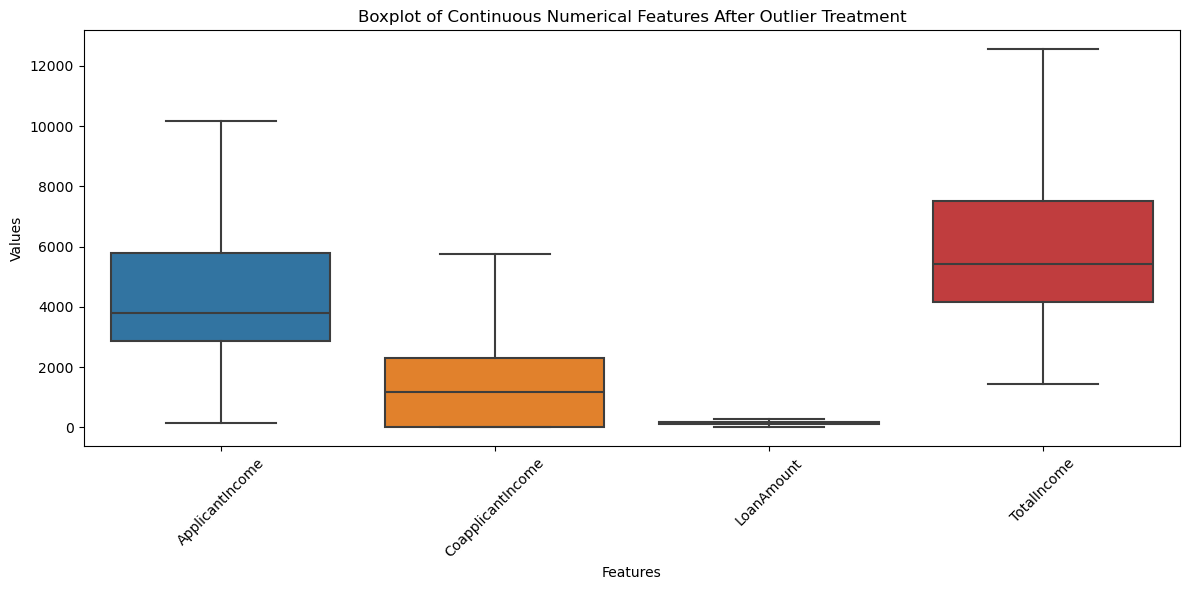

In [39]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_ml_outlier_treated[outlier_features])

plt.title('Boxplot of Continuous Numerical Features After Outlier Treatment')
plt.xlabel('Features')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.19 Correlation Analysis

Correlation analysis is performed to identify relationships between numerical features and detect potentially redundant variables.

A correlation heatmap is used to visualize the strength and direction of relationships between the features. Highly correlated features may provide overlapping information and can potentially affect some machine learning algorithms.

In [40]:
# Calculate the correlation matrix
correlation_matrix = df_ml_outlier_treated.corr()

# Display the correlation matrix
correlation_matrix

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Property_Area_Semiurban,Property_Area_Urban
Gender,1.000000,0.364569,0.172914,-0.045364,-0.000525,0.065040,0.192438,0.143426,-0.074030,0.009170,0.017987,0.150640,-0.108623,0.034530
Married,0.364569,1.000000,0.334216,-0.012304,0.004489,0.022480,0.221217,0.177417,-0.100912,0.010938,0.091478,0.127880,0.005845,0.000546
Dependents,0.172914,0.334216,1.000000,-0.055752,0.056798,0.111565,-0.031510,0.164515,-0.103864,-0.040160,0.010118,0.096915,0.001924,-0.001198
Education,-0.045364,-0.012304,-0.055752,1.000000,0.010383,0.203087,0.049895,0.176194,0.073928,0.073658,0.085884,0.223942,0.039410,0.034279
Self_Employed,-0.000525,0.004489,0.056798,0.010383,1.000000,0.237122,-0.032784,0.114297,-0.033739,-0.001550,-0.003700,0.197071,0.008710,-0.030338
ApplicantIncome,0.065040,0.022480,0.111565,0.203087,0.237122,1.000000,-0.228956,0.557953,-0.023926,0.035345,-0.000442,0.795620,-0.016858,-0.015294
CoapplicantIncome,0.192438,0.221217,-0.031510,0.049895,-0.032784,-0.228956,1.000000,0.265021,-0.029295,-0.001710,0.011983,0.351661,-0.018945,-0.052557
LoanAmount,0.143426,0.177417,0.164515,0.176194,0.114297,0.557953,0.265021,1.000000,0.063612,0.004320,-0.047262,0.684910,0.007546,-0.066726
Loan_Amount_Term,-0.074030,-0.100912,-0.103864,0.073928,-0.033739,-0.023926,-0.029295,0.063612,1.000000,-0.004705,-0.022549,-0.044581,0.059141,-0.094279
Credit_History,0.009170,0.010938,-0.040160,0.073658,-0.001550,0.035345,-0.001710,0.004320,-0.004705,1.000000,0.540556,0.030412,0.035976,-0.016934


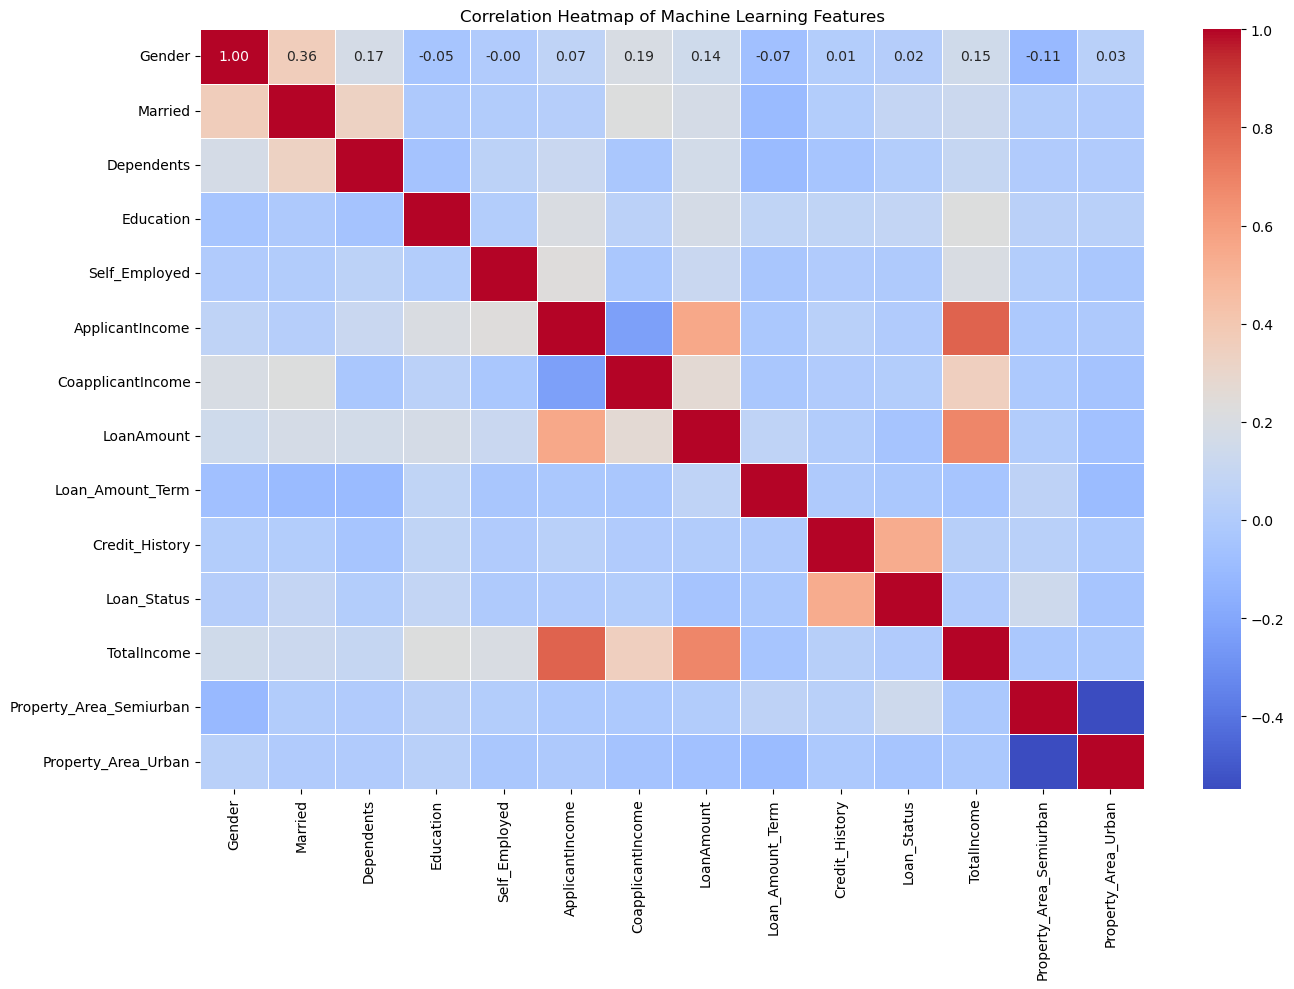

In [41]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Machine Learning Features')
plt.tight_layout()
plt.show()

### Correlation Analysis

A correlation heatmap was generated to examine the relationships between the machine learning features. Correlation coefficients range from -1 to +1, where values closer to +1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values close to 0 indicate a weak or negligible linear relationship.

The strongest relationship with the target variable, Loan_Status, is Credit_History, with a correlation of approximately 0.54. This indicates a moderate positive relationship, suggesting that applicants with a positive credit history are more likely to have their loans approved.

Property_Area_Semiurban has a weak positive correlation with Loan_Status (approximately 0.14), while Married and Education have relatively weak positive correlations of approximately 0.09 and 0.09 respectively. The remaining variables have very weak correlations with Loan_Status, including ApplicantIncome (-0.00), CoapplicantIncome (0.01), LoanAmount (-0.05), Loan_Amount_Term (-0.02), and TotalIncome (0.00).

Among the predictor variables, ApplicantIncome and TotalIncome have a relatively strong positive correlation of approximately 0.80. LoanAmount also has a moderately strong positive relationship with ApplicantIncome (approximately 0.56) and TotalIncome (approximately 0.68). These relationships are reasonable because applicants with higher incomes may qualify for larger loan amounts.

The negative correlation between Property_Area_Semiurban and Property_Area_Urban (approximately -0.55) is expected because these variables are dummy-encoded representations of different property-area categories.

Overall, Credit_History shows the strongest linear relationship with Loan_Status and is therefore an important feature for the subsequent machine learning models. The correlation analysis also indicates that some predictor variables are correlated with each other, particularly ApplicantIncome, LoanAmount, and TotalIncome, which should be considered during model development.

## Feature Selection

Feature selection is the process of identifying the most relevant variables for predicting loan approval while reducing redundant or unnecessary features.

The correlation analysis performed in Section 3.19 is used as an initial guide for identifying potentially redundant features. Particular attention is given to features with strong relationships with the target variable and features that are highly correlated with one another.

Feature selection can improve model performance, reduce complexity, and help minimize the risk of multicollinearity.

In [43]:
# Calculate correlations between all features and the target variable

target_correlation = (
    correlation_matrix['Loan_Status']
    .sort_values(ascending=False)
)

print("Correlation of features with Loan_Status:")
target_correlation

Correlation of features with Loan_Status:


Loan_Status                1.000000
Credit_History             0.540556
Property_Area_Semiurban    0.136540
Married                    0.091478
Education                  0.085884
Gender                     0.017987
CoapplicantIncome          0.011983
Dependents                 0.010118
TotalIncome                0.002220
ApplicantIncome           -0.000442
Self_Employed             -0.003700
Loan_Amount_Term          -0.022549
Property_Area_Urban       -0.043621
LoanAmount                -0.047262
Name: Loan_Status, dtype: float64

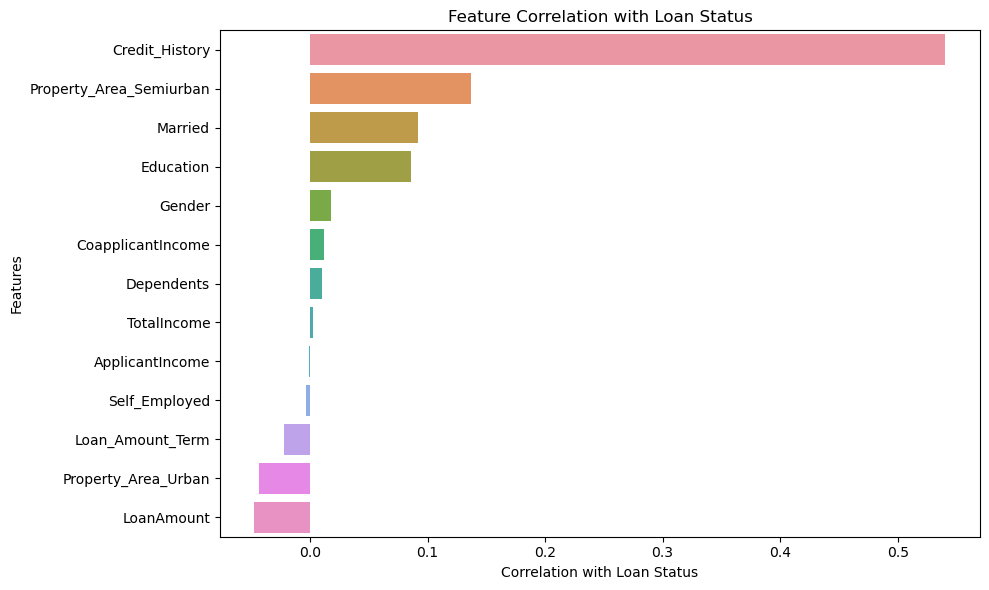

In [44]:
# Remove the target itself for visualization
feature_target_corr = target_correlation.drop('Loan_Status')

plt.figure(figsize=(10, 6))

sns.barplot(
    x=feature_target_corr.values,
    y=feature_target_corr.index
)

plt.title('Feature Correlation with Loan Status')
plt.xlabel('Correlation with Loan Status')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Interpretation

The correlation analysis shows that `Credit_History` has the strongest relationship with loan approval, with a correlation coefficient of approximately 0.54. This indicates a moderate positive relationship between an applicant's credit history and the likelihood of loan approval.

`Property_Area_Semiurban` has a weaker positive relationship with loan status, while most other individual features have relatively weak linear correlations with the target variable.

However, weak correlation does not necessarily mean that a feature is useless. Some machine learning algorithms can identify nonlinear relationships and interactions that are not captured by Pearson correlation. Therefore, feature selection should consider both statistical relationships and the business relevance of the variables.

In [45]:
# Display strong correlations between independent features

feature_columns = [
    column for column in df_ml_outlier_treated.columns
    if column != 'Loan_Status'
]

feature_correlation = (
    df_ml_outlier_treated[feature_columns]
    .corr()
)

# Find feature pairs with absolute correlation >= 0.70
high_correlations = []

for i in range(len(feature_correlation.columns)):
    for j in range(i + 1, len(feature_correlation.columns)):
        
        correlation_value = feature_correlation.iloc[i, j]
        
        if abs(correlation_value) >= 0.70:
            high_correlations.append({
                'Feature 1': feature_correlation.columns[i],
                'Feature 2': feature_correlation.columns[j],
                'Correlation': correlation_value
            })

high_correlation_df = pd.DataFrame(high_correlations)

high_correlation_df

,Feature 1,Feature 2,Correlation
0,ApplicantIncome,TotalIncome,0.79562


### Interpretation of Highly Correlated Features

The correlation analysis identified a strong relationship between `ApplicantIncome` and `TotalIncome` (approximately 0.80).

This relationship is expected because `TotalIncome` was engineered by combining `ApplicantIncome` and `CoapplicantIncome`. Therefore, `TotalIncome` contains much of the information already represented by `ApplicantIncome`.

Keeping both variables may introduce redundancy into the dataset. To simplify the feature set and reduce potential multicollinearity, `ApplicantIncome` is considered for removal while retaining `TotalIncome` as the combined income measure.

The `Property_Area_Semiurban` and `Property_Area_Urban` variables also show a negative correlation of approximately -0.55. This is expected because they are one-hot encoded representations of the original `Property_Area` categorical variable. They are therefore retained because they represent different property-area categories rather than duplicate measurements.

In [46]:
# Create a copy of the outlier-treated dataset
df_feature_selected = df_ml_outlier_treated.copy()

# Remove the redundant ApplicantIncome feature
df_feature_selected = df_feature_selected.drop(
    columns=['ApplicantIncome']
)

print("Feature selection completed.")
print("\nRemaining features:")
print(df_feature_selected.columns.tolist())

print("\nDataset shape after feature selection:")
print(df_feature_selected.shape)

Feature selection completed.

Remaining features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'TotalIncome', 'Property_Area_Semiurban', 'Property_Area_Urban']

Dataset shape after feature selection:
(614, 13)


In [47]:
# Display the final feature set

df_feature_selected.head(10)

,Gender,Married,Dependents,Education,Self_Employed,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,0.000,128.0,360.0,1,1,5849.000,0,1
1,1,1,1,1,0,1508.000,128.0,360.0,1,0,6091.000,0,0
2,1,1,0,1,1,0.000,66.0,360.0,1,1,3000.000,0,1
3,1,1,0,0,0,2358.000,120.0,360.0,1,1,4941.000,0,1
4,1,0,0,1,0,0.000,141.0,360.0,1,1,6000.000,0,1
5,1,1,2,1,1,4196.000,261.5,360.0,1,1,9613.000,0,1
6,1,1,0,0,0,1516.000,95.0,360.0,1,1,3849.000,0,1
7,1,1,3,1,0,2504.000,158.0,360.0,0,0,5540.000,1,0
8,1,1,2,1,0,1526.000,168.0,360.0,1,1,5532.000,0,1
9,1,1,1,1,0,5743.125,261.5,360.0,1,0,12555.375,1,0


In [48]:
print("Final feature list:")
for i, column in enumerate(df_feature_selected.columns, start=1):
    print(f"{i}. {column}")

Final feature list:
1. Gender
2. Married
3. Dependents
4. Education
5. Self_Employed
6. CoapplicantIncome
7. LoanAmount
8. Loan_Amount_Term
9. Credit_History
10. Loan_Status
11. TotalIncome
12. Property_Area_Semiurban
13. Property_Area_Urban


### Feature Selection Summary

Based on the correlation analysis, `Credit_History` was identified as the feature with the strongest relationship with the target variable `Loan_Status`, with a correlation of approximately 0.54.

A strong relationship was also observed between `ApplicantIncome` and the engineered `TotalIncome` feature (approximately 0.80). Since `TotalIncome` combines applicant and coapplicant income, retaining both variables would introduce redundant information. Therefore, `ApplicantIncome` was removed while `TotalIncome` was retained.

The one-hot encoded property-area variables were retained because they represent distinct categories from the original `Property_Area` variable.

The feature selection process reduced the dataset from 14 to 13 columns while preserving the target variable and the most relevant business information.

## Feature Scaling

Feature scaling is applied to the continuous numerical variables to ensure that variables with larger numerical ranges do not disproportionately influence machine learning algorithms.

The `StandardScaler` technique is selected because it transforms continuous numerical features to have a mean of approximately 0 and a standard deviation of approximately 1.

Scaling is applied only to the continuous financial variables:

- `CoapplicantIncome`
- `LoanAmount`
- `TotalIncome`

Binary encoded categorical variables and the target variable `Loan_Status` are not scaled because their numerical representation already has an interpretable categorical meaning.

`Loan_Amount_Term` is also retained in its original form because it represents discrete loan repayment-term categories rather than a continuous financial measurement.

In [49]:
from sklearn.preprocessing import StandardScaler

# Create a copy of the feature-selected dataset
df_ml_ready = df_feature_selected.copy()

# Continuous numerical features to be scaled
scaling_features = [
    'CoapplicantIncome',
    'LoanAmount',
    'TotalIncome'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling
df_ml_ready[scaling_features] = scaler.fit_transform(
    df_ml_ready[scaling_features]
)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [50]:
# Display summary statistics after scaling
df_ml_ready[scaling_features].describe()

,CoapplicantIncome,LoanAmount,TotalIncome
count,6.140000e+02,6.140000e+02,6.140000e+02
mean,9.257886e-17,1.012581e-16,1.996232e-16
std,1.000815e+00,1.000815e+00,1.000815e+00
min,-8.745873e-01,-2.303171e+00,-1.654013e+00
25%,-8.745873e-01,-6.659388e-01,-7.060235e-01
50%,-1.424288e-01,-1.680408e-01,-2.708322e-01
75%,5.406008e-01,4.913377e-01,4.618239e-01
max,2.663383e+00,2.227252e+00,2.213595e+00


In [51]:
print("Scaled feature means:")
print(df_ml_ready[scaling_features].mean())

print("\nScaled feature standard deviations:")
print(df_ml_ready[scaling_features].std())

Scaled feature means:
CoapplicantIncome    9.257886e-17
LoanAmount           1.012581e-16
TotalIncome          1.996232e-16
dtype: float64

Scaled feature standard deviations:
CoapplicantIncome    1.000815
LoanAmount           1.000815
TotalIncome          1.000815
dtype: float64


### Interpretation

The StandardScaler transformation was successfully applied to the continuous numerical features.

The mean of each scaled feature is approximately zero, while the standard deviation is approximately one. This confirms that the features have been standardized successfully.

Standardization places `CoapplicantIncome`, `LoanAmount`, and `TotalIncome` on a comparable scale, which can improve the performance of machine learning algorithms that are sensitive to feature magnitude.

The encoded categorical variables and target variable were not scaled because their numerical values represent categories rather than continuous measurements.

### Loan Status Distribution

The distribution of the target variable, `Loan_Status`, is visualized to understand the proportion of approved and rejected loan applications in the dataset.

This visualization helps assess whether the target classes are reasonably balanced or whether there is a potential class imbalance that should be considered during machine learning model development.

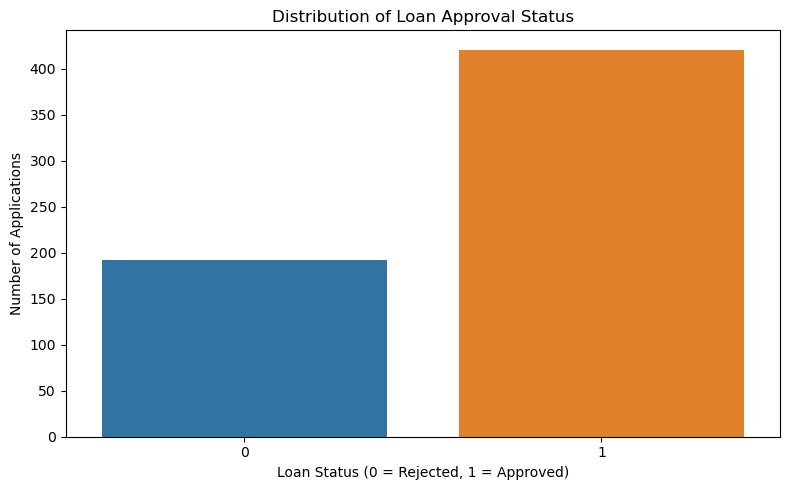

In [64]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_ml_ready,
    x='Loan_Status'
)

plt.title('Distribution of Loan Approval Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Number of Applications')

plt.tight_layout()
plt.show()

### 3.25 Total Income and Loan Approval

The relationship between applicants' total income and loan approval status is visualized using a boxplot.

The visualization helps compare the income distributions of approved and rejected loan applications and provides an additional business perspective on whether income may be associated with loan approval.

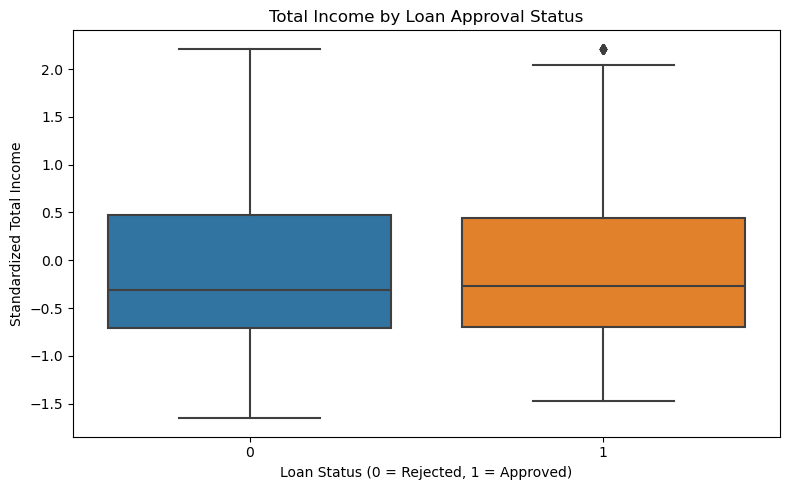

In [65]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_ml_ready,
    x='Loan_Status',
    y='TotalIncome'
)

plt.title('Total Income by Loan Approval Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Standardized Total Income')

plt.tight_layout()
plt.show()

## Final Machine-Learning-Ready Dataset

Following data cleaning, feature engineering, categorical encoding, outlier treatment, feature selection, and feature scaling, the dataset is now prepared for machine learning.

The final dataset contains 614 observations and 13 numerical variables. The target variable, `Loan_Status`, is retained for predictive modelling.

`ApplicantIncome` was removed during feature selection because it was strongly correlated with the engineered `TotalIncome` feature. `TotalIncome` was retained as a combined measure of applicant and coapplicant income.

The continuous financial variables `CoapplicantIncome`, `LoanAmount`, and `TotalIncome` were standardized using `StandardScaler`.

The final dataset will now be validated to ensure that it contains no missing values, no duplicate records, and no remaining non-numerical variables.

In [52]:
# Display the first 10 rows of the final dataset
df_ml_ready.head(10)

,Gender,Married,Dependents,Education,Self_Employed,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,-0.874587,-0.168041,360.0,1,1,-0.120316,0,1
1,1,1,1,1,0,0.054395,-0.168041,360.0,1,0,-0.036097,0,0
2,1,1,0,1,1,-0.874587,-1.280462,360.0,1,1,-1.111808,0,1
3,1,1,0,0,0,0.578025,-0.311579,360.0,1,1,-0.436313,0,1
4,1,0,0,1,0,-0.874587,0.065209,360.0,1,1,-0.067766,0,1
5,1,1,2,1,1,1.710299,2.227252,360.0,1,1,1.189608,0,1
6,1,1,0,0,0,0.059323,-0.760136,360.0,1,1,-0.816344,0,1
7,1,1,3,1,0,0.667966,0.370227,360.0,0,0,-0.227853,1,0
8,1,1,2,1,0,0.065483,0.549650,360.0,1,1,-0.230637,0,1
9,1,1,1,1,0,2.663383,2.227252,360.0,1,0,2.213595,1,0


In [53]:
# Check the final dataset dimensions
print("Final dataset shape:", df_ml_ready.shape)

Final dataset shape: (614, 13)


## Final Data Validation

A final validation is performed to confirm that the processed dataset satisfies the requirements for machine learning.

The validation checks for:

- Missing values
- Duplicate records
- Non-numerical variables
- Presence of the target variable
- Final dataset dimensions

These checks ensure that the preprocessing workflow has produced a consistent and machine-learning-ready dataset.

In [55]:
# Final machine-learning readiness checks

print("===== FINAL MACHINE LEARNING READINESS CHECK =====")

print("Rows:", df_ml_ready.shape[0])
print("Columns:", df_ml_ready.shape[1])

print("\nTotal missing values:")
print(df_ml_ready.isnull().sum().sum())

print("\nDuplicate records:")
print(df_ml_ready.duplicated().sum())

print("\nNon-numerical columns:")
print(df_ml_ready.select_dtypes(include=['object']).columns.tolist())

print("\nTarget variable present:")
print('Loan_Status' in df_ml_ready.columns)

===== FINAL MACHINE LEARNING READINESS CHECK =====
Rows: 614
Columns: 13

Total missing values:
0

Duplicate records:
1

Non-numerical columns:
[]

Target variable present:
True


In [56]:
# Automated readiness confirmation

if (
    df_ml_ready.isnull().sum().sum() == 0
    and df_ml_ready.duplicated().sum() == 0
    and len(df_ml_ready.select_dtypes(include=['object']).columns) == 0
    and 'Loan_Status' in df_ml_ready.columns
):
    print("Dataset is ready for machine learning.")
else:
    print("Further preprocessing is required.")

Further preprocessing is required.


### Duplicate Record Removal

The final validation identified one duplicate record in the machine-learning-ready dataset.

Because duplicate observations can give excessive weight to the same record during model training, the duplicate record is removed before the final dataset is exported.

The dataset is then revalidated to confirm that no duplicate records remain.

In [57]:
# Remove duplicate records from the final dataset

print("Duplicates before removal:", df_ml_ready.duplicated().sum())

df_ml_ready = df_ml_ready.drop_duplicates().reset_index(drop=True)

print("Duplicates after removal:", df_ml_ready.duplicated().sum())
print("Updated dataset shape:", df_ml_ready.shape)

Duplicates before removal: 1
Duplicates after removal: 0
Updated dataset shape: (613, 13)


In [58]:
# Final validation after duplicate removal

print("===== FINAL MACHINE LEARNING READINESS CHECK =====")

print("Rows:", df_ml_ready.shape[0])
print("Columns:", df_ml_ready.shape[1])

print("\nTotal missing values:")
print(df_ml_ready.isnull().sum().sum())

print("\nDuplicate records:")
print(df_ml_ready.duplicated().sum())

print("\nNon-numerical columns:")
print(df_ml_ready.select_dtypes(include=['object']).columns.tolist())

print("\nTarget variable present:")
print('Loan_Status' in df_ml_ready.columns)

===== FINAL MACHINE LEARNING READINESS CHECK =====
Rows: 613
Columns: 13

Total missing values:
0

Duplicate records:
0

Non-numerical columns:
[]

Target variable present:
True


In [59]:
# Confirm whether the dataset is machine-learning ready

if (
    df_ml_ready.isnull().sum().sum() == 0
    and df_ml_ready.duplicated().sum() == 0
    and len(df_ml_ready.select_dtypes(include=['object']).columns) == 0
    and 'Loan_Status' in df_ml_ready.columns
):
    print("Dataset is ready for machine learning.")
else:
    print("Further preprocessing is required.")

Dataset is ready for machine learning.


## Export Machine-Learning-Ready Dataset

After completing data cleaning, feature engineering, categorical encoding, outlier treatment, feature selection, scaling, and final validation, the processed dataset is exported as a CSV file.

The final dataset contains 613 observations and 13 numerical variables, including the `Loan_Status` target variable.

This dataset is the final machine-learning-ready version that can be used as input for subsequent predictive modelling.

In [60]:
# Export the final machine-learning-ready dataset

df_ml_ready.to_csv(
    'Loan_Prediction_Machine_Learning_Ready_Dataset.csv',
    index=False
)

print("Machine-learning-ready dataset saved successfully.")
print("Final shape:", df_ml_ready.shape)

Machine-learning-ready dataset saved successfully.
Final shape: (613, 13)


In [61]:
import os

file_name = 'Loan_Prediction_Machine_Learning_Ready_Dataset.csv'

print("File exists:", os.path.exists(file_name))

if os.path.exists(file_name):
    print("File size:", round(os.path.getsize(file_name) / 1024, 2), "KB")

File exists: True
File size: 50.54 KB


## Conclusion

The loan prediction dataset has been successfully transformed into a machine-learning-ready dataset.

The preprocessing workflow included:

- Missing-value assessment and appropriate handling
- Duplicate detection and removal
- Data type validation
- Categorical variable encoding
- Creation of the `TotalIncome` feature
- Removal of the redundant `ApplicantIncome` feature
- Outlier detection using the IQR method
- IQR capping of continuous financial variables
- Correlation analysis
- Feature selection
- Standardization of continuous numerical features
- Final machine-learning readiness validation

After preprocessing, the final dataset contains **613 observations and 13 numerical features**, including the target variable `Loan_Status`.

The final validation confirmed that the dataset contains:

- **0 missing values**
- **0 duplicate records**
- **0 non-numerical columns**
- **The target variable `Loan_Status`**

Therefore, the dataset is considered **ready for use in subsequent machine-learning modelling**.